# Define the LeNet5 Model

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Visualizing Initial Filters

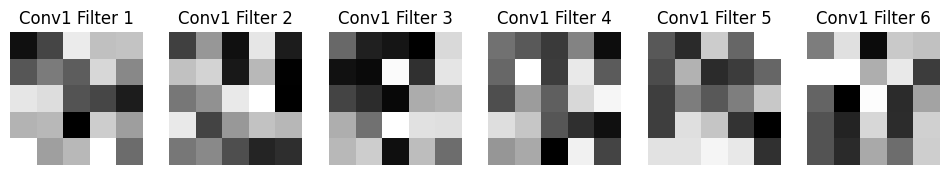

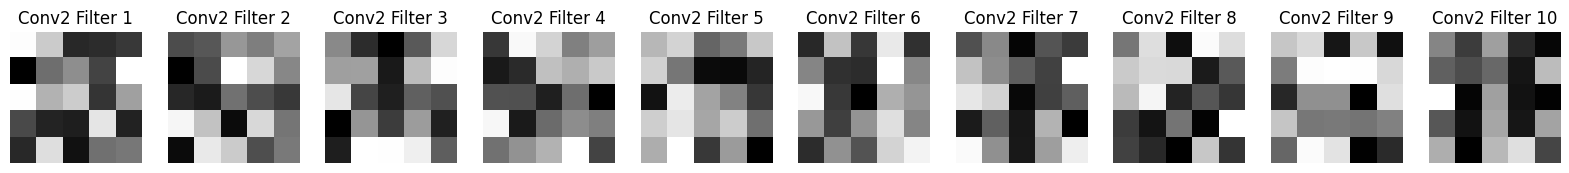

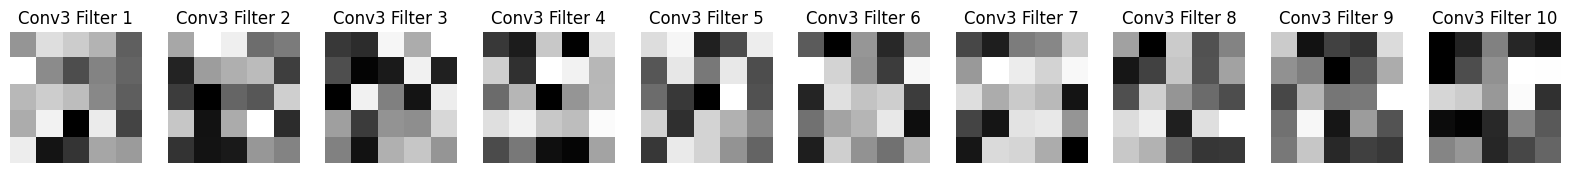

In [4]:
import matplotlib.pyplot as plt

model = LeNet5()

# Visualize the filters of the convolutional layers
layers = [model.conv1, model.conv2, model.conv3]
layer_names = ['Conv1', 'Conv2', 'Conv3']

for layer, name in zip(layers, layer_names):
    weights = layer.weight.data.numpy()
    num_filters = weights.shape[0]
    fig, axes = plt.subplots(1, min(num_filters, 10), figsize=(min(num_filters, 10)*2, 2))
    if num_filters == 1:
        axes = [axes]
    for i in range(min(num_filters, 10)):
        axes[i].imshow(weights[i, 0], cmap='gray')
        axes[i].set_title(f'{name} Filter {i+1}')
        axes[i].axis('off')
    plt.show()

# Load MNIST Dataset and Display Samples

100.0%
100.0%
100.0%
100.0%


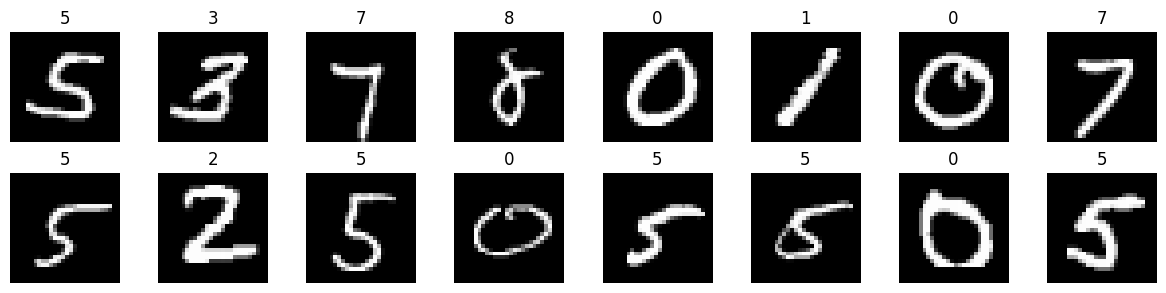

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Download MNIST and create a dataloader
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root='data', train=True, download=True, transform=transform)
train_loader = DataLoader(mnist_train, batch_size=16, shuffle=True)

# Show a few examples
data_iter = iter(train_loader)
images, labels = next(data_iter)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for idx in range(16):
    ax = axes[idx // 8, idx % 8]
    ax.imshow(images[idx].squeeze(), cmap='gray')
    ax.set_title(str(labels[idx].item()))
    ax.axis('off')
plt.tight_layout()
plt.show()

# Train LeNet5 on MNIST

In [6]:
import torch

# Prepare Device and Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 2
for epoch in range(num_epochs):
    running_loss = 0.0
    for batch_idx, (inputs, targets) in enumerate(train_loader, 1):
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % 100 == 0:
            avg_loss = running_loss / 100
            print(f"Epoch [{epoch+1}/{num_epochs}]  Batch [{batch_idx}]  Loss: {avg_loss:.4f}")
            running_loss = 0.0

print('Training complete.')

Epoch [1/2]  Batch [100]  Loss: 1.6835
Epoch [1/2]  Batch [200]  Loss: 0.5864
Epoch [1/2]  Batch [300]  Loss: 0.4052
Epoch [1/2]  Batch [400]  Loss: 0.2609
Epoch [1/2]  Batch [500]  Loss: 0.2335
Epoch [1/2]  Batch [600]  Loss: 0.2096
Epoch [1/2]  Batch [700]  Loss: 0.1951
Epoch [1/2]  Batch [800]  Loss: 0.1694
Epoch [1/2]  Batch [900]  Loss: 0.1556
Epoch [1/2]  Batch [1000]  Loss: 0.1558
Epoch [1/2]  Batch [1100]  Loss: 0.1270
Epoch [1/2]  Batch [1200]  Loss: 0.1326
Epoch [1/2]  Batch [1300]  Loss: 0.1282
Epoch [1/2]  Batch [1400]  Loss: 0.1137
Epoch [1/2]  Batch [1500]  Loss: 0.1200
Epoch [1/2]  Batch [1600]  Loss: 0.1106
Epoch [1/2]  Batch [1700]  Loss: 0.1186
Epoch [1/2]  Batch [1800]  Loss: 0.0975
Epoch [1/2]  Batch [1900]  Loss: 0.1095
Epoch [1/2]  Batch [2000]  Loss: 0.1007
Epoch [1/2]  Batch [2100]  Loss: 0.0941
Epoch [1/2]  Batch [2200]  Loss: 0.0786
Epoch [1/2]  Batch [2300]  Loss: 0.0787
Epoch [1/2]  Batch [2400]  Loss: 0.0963
Epoch [1/2]  Batch [2500]  Loss: 0.0901
Epoch [1/

# Evaluate on MNIST Test Set

In [7]:
# Load test set
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

model.eval()
correct = 0
total = 0
loss_total = 0.0

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_total += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

avg_loss = loss_total / total
accuracy = correct / total * 100
print(f"Test Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

Test Loss: 0.0465 | Test Accuracy: 98.61%


# Display Misclassified Examples

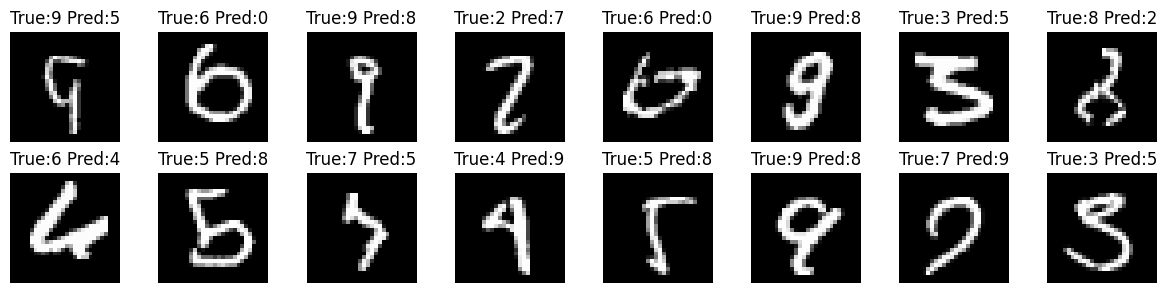

In [9]:
# Collect some misclassified examples
misclassified = []
model.eval()

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        mismatches = (predicted != targets).nonzero(as_tuple=False)
        for idx in mismatches[:, 0].tolist():
            misclassified.append((inputs[idx].cpu(), targets[idx].cpu().item(), predicted[idx].cpu().item()))
            if len(misclassified) >= 16:
                break
        if len(misclassified) >= 16:
            break

# Plot misclassified samples
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, (img, true_lbl, pred_lbl) in enumerate(misclassified):
    ax = axes[i // 8, i % 8]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'True:{true_lbl} Pred:{pred_lbl}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Save Trained Model

In [10]:
# Save the model state_dict
model_path = 'lenet5_mnist.pth'
torch.save(model.state_dict(), model_path)
print(f'Model saved to {model_path}')

Model saved to lenet5_mnist.pth


# Load Saved Model

In [12]:
# Instantiate model and load weights
loaded_model = LeNet5().to(device)
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.eval()

print(f"Loaded model from {model_path} and set to eval mode.")

Loaded model from lenet5_mnist.pth and set to eval mode.


# Visualize Output of First Convolutional Layer

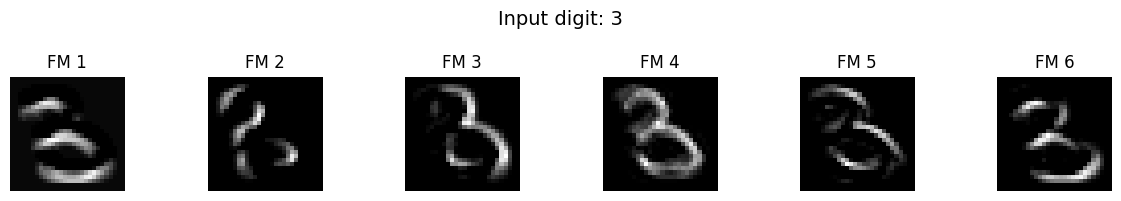

In [18]:
import random

# Get a batch from the test loader
sample_inputs, sample_labels = next(iter(test_loader))
idx = random.randrange(sample_inputs.size(0))
input_img = sample_inputs[idx:idx+1].to(device)
input_label = sample_labels[idx].item()

# Forward through first conv layer + activation
with torch.no_grad():
    conv1_out = loaded_model.conv1(input_img)
    conv1_out = F.relu(conv1_out)

# Plot the feature maps of the first conv layer
feature_maps = conv1_out.cpu().squeeze().numpy()
num_maps = feature_maps.shape[0]

fig, axes = plt.subplots(1, num_maps, figsize=(num_maps * 2, 2))
fig.suptitle(f'Input digit: {input_label}', fontsize=14)
for i in range(num_maps):
    ax = axes[i]
    ax.imshow(feature_maps[i], cmap='gray')
    ax.set_title(f'FM {i+1}')
    ax.axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()